# Contract Clause Risk Analysis — QLoRA Fine-tuning
**Model:** LLaMA 3.1 8B Instruct  
**Method:** QLoRA (4-bit quantization + LoRA adapters)  
**Task:** Role-conditioned risk classification (Licensor / Licensee → Low / Medium / High)

### Before running:
1. Runtime → Change runtime type → **T4 GPU**
2. Upload `train.jsonl` and `val.jsonl` to the Colab file browser (left panel)
3. You'll need a Hugging Face token with access to LLaMA 3.1 8B (request access at hf.co/meta-llama if needed)

## 1. Install Dependencies

In [ ]:
%%capture
!pip install -q \
    transformers==4.44.0 \
    peft==0.12.0 \
    trl==0.10.1 \
    bitsandbytes==0.43.3 \
    accelerate==0.33.0 \
    datasets==2.21.0 \
    scikit-learn \
    seaborn \
    matplotlib

In [ ]:
!pip install --upgrade --force-reinstall numpy pandas pyarrow datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63

In [ ]:
!pip install huggingface-hub==0.23.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.6/402.6 kB 16.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.9.2
    Uninstalling huggingface_hub-1.9.2:
      Successfully uninstalled huggingface_hub-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.4.4 which is incompatible.
datasets 4.8.4 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.23.4 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.4 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.4 which is incompatible.


In [ ]:
!pip uninstall -y numpy torch transformers bitsandbytes triton accelerate

In [ ]:
!pip install -q \
numpy==1.26.4 \
torch==2.2.1 --index-url https://download.pytorch.org/whl/cu121 \
transformers==4.43.3 \
accelerate==0.31.0 \
bitsandbytes==0.43.1 \
triton==2.2.0

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement transformers==4.43.3 (from versions: none)
ERROR: No matching distribution found for transformers==4.43.3


In [ ]:
import os
os._exit(0)

## 2. Authenticate with Hugging Face
You need this to download LLaMA 3.1 8B (gated model).

In [ ]:
# Mount Google Drive so model weights are saved there permanently
from google.colab import drive
drive.mount('/content/drive')

import os
# Change this folder name if you like — it will be created if it doesn't exist
GDRIVE_OUTPUT_DIR = "/content/drive/MyDrive/qlora_output"
os.makedirs(GDRIVE_OUTPUT_DIR, exist_ok=True)
print(f"Google Drive mounted. Model will be saved to: {GDRIVE_OUTPUT_DIR}")

In [6]:
from huggingface_hub import login
login()  # paste your HF token when prompted

## 3. Config — all hyperparameters in one place

In [1]:
# ── Paths ──────────────────────────────────────────────────────
TRAIN_FILE     = "/content/train.jsonl"
VAL_FILE       = "/content/val.jsonl"
OUTPUT_DIR     = GDRIVE_OUTPUT_DIR  # saved to Google Drive

# ── Model ──────────────────────────────────────────────────────
MODEL_ID       = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# ── QLoRA ──────────────────────────────────────────────────────
LORA_RANK      = 16    # size of the adapter matrices; higher = more capacity
LORA_ALPHA     = 32    # scaling factor; rule of thumb: 2x rank
LORA_DROPOUT   = 0.05
# which layers to add LoRA adapters to (attention projections are standard)
LORA_MODULES   = ["q_proj", "k_proj", "v_proj", "o_proj"]

# ── Training ───────────────────────────────────────────────────
EPOCHS         = 3
BATCH_SIZE     = 2     # per device; keep low for T4
GRAD_ACCUM     = 8     # effective batch size = BATCH_SIZE * GRAD_ACCUM = 16
LR             = 2e-4
MAX_SEQ_LEN    = 512   # our prompts are ~400 tokens, 512 is safe
WARMUP_RATIO   = 0.05

SEED           = 42

## 4. Load Dataset

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files={"train": TRAIN_FILE, "validation": VAL_FILE}
)

print(dataset)
print("\nSample training example:")
print(dataset["train"][0]["text"])

DatasetDict({
    train: Dataset({
        features: ['text', '_meta'],
        num_rows: 199
    })
    validation: Dataset({
        features: ['text', '_meta'],
        num_rows: 35
    })
})

Sample training example:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a legal risk analyst specializing in licensing agreements. Your task is to analyze a contract clause and assess its risk level from a specific party's perspective.<|eot_id|><|start_header_id|>user<|end_header_id|>

Analyze the following contract clause from the perspective of the **Licensor**.

Clause:
"""
1.102 “Subsequent Indication” means each indication in the Field other than the Initial Indication, including the Monotherapy Indication; provided that Subsequent Indications must be distinct indications and broadening the use of a Licensed Product for a particular indication shall not be deemed a new indication. By way of illustration, extending the use of the Licensed Product to patients of differ

## 5. Load Model in 4-bit (QLoRA)

In [3]:
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",        # NormalFloat4 — best for normally distributed weights
    bnb_4bit_compute_dtype=torch.bfloat16,  # compute in bf16 for stability
    bnb_4bit_use_double_quant=True,   # quantize the quantization constants too (saves ~0.4GB)
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token  # LLaMA has no pad token by default
tokenizer.padding_side = "right"           # pad on right for causal LM training

print(f"Model loaded. Parameters: {model.num_parameters()/1e9:.1f}B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded. Parameters: 8.0B


In [4]:
%pip install -U bitsandbytes>=0.46.1

## 6. Attach LoRA Adapters

In [4]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Prepare the quantized model for training
# (enables gradient checkpointing, casts layer norms to float32)
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_MODULES,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expected: ~0.5-1% of total params — that's the LoRA adapter size

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695


## 7. Train

In [4]:
!pip install -q \
transformers==4.44.2 \
trl==0.9.6 \
accelerate==0.33.0 \
bitsandbytes==0.43.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 39.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 

In [8]:
!pip install -q trl==0.8.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 51.6 MB/s eta 0:00:00


In [ ]:
import os
os._exit(0)

In [5]:
from transformers import TrainingArguments
from trl import SFTTrainer

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    bf16=True,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",   # set to "wandb" if you want experiment tracking
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LEN,
)

print("Starting training...")
trainer.train()
print("Training complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:280: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:318: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/199 [00:00<?, ? examples/s]

Map:   0%|          | 0/35 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
0,2.109700,1.246434
2,1.069100,1.070061


We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an excepti

Training complete.


## 8. Save the LoRA Adapter

In [6]:
# Saves only the adapter weights (~100MB), not the full model
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Adapter saved to {OUTPUT_DIR}")

Adapter saved to ./qlora_output


## 9. Evaluate — Extract Predictions on Val Set

We run inference on each val example, parse the predicted risk label out of the generated text, and compare against the ground truth.

In [7]:
import json
import re
from tqdm import tqdm

def extract_risk_label(generated_text: str) -> str:
    """
    Parse 'Risk Level: High' from model output.
    Returns 'Unknown' if parsing fails.
    """
    match = re.search(r"Risk Level:\s*(Low|Medium|High)", generated_text, re.IGNORECASE)
    if match:
        return match.group(1).capitalize()
    # fallback: look for standalone label
    match = re.search(r"\b(Low|Medium|High)\b", generated_text, re.IGNORECASE)
    if match:
        return match.group(1).capitalize()
    return "Unknown"


def get_prompt_only(full_text: str) -> str:
    """
    Strip the assistant response from the full training text,
    leaving just the prompt up to the assistant header.
    At inference time we feed only the prompt and let the model generate.
    """
    marker = "<|start_header_id|>assistant<|end_header_id|>\n\n"
    idx = full_text.find(marker)
    if idx != -1:
        return full_text[:idx + len(marker)]
    return full_text


def get_ground_truth_label(full_text: str) -> str:
    """Extract the ground truth label from the assistant response in the training text."""
    marker = "<|start_header_id|>assistant<|end_header_id|>\n\n"
    idx = full_text.find(marker)
    if idx != -1:
        response = full_text[idx + len(marker):]
        return extract_risk_label(response)
    return "Unknown"


# Load val examples
val_examples = []
with open(VAL_FILE) as f:
    for line in f:
        val_examples.append(json.loads(line.strip()))

print(f"Running inference on {len(val_examples)} validation examples...")

# Set model to eval mode
model.eval()

y_true, y_pred, parties = [], [], []

for ex in tqdm(val_examples):
    full_text = ex["text"]
    prompt    = get_prompt_only(full_text)
    gt_label  = get_ground_truth_label(full_text)
    party     = ex.get("_meta", {}).get("party", "Unknown")

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,      # greedy decoding for deterministic eval
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    generated  = tokenizer.decode(new_tokens, skip_special_tokens=True)
    pred_label = extract_risk_label(generated)

    y_true.append(gt_label)
    y_pred.append(pred_label)
    parties.append(party)

print("Inference complete.")

Running inference on 35 validation examples...


  0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
100%|██████████| 35/35 [03:25<00:00,  5.88s/it]

Inference complete.


## 10. Performance Metrics

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

LABELS = ["Low", "Medium", "High"]

# ── Overall metrics ───────────────────────────────────────────
print("=" * 55)
print("OVERALL PERFORMANCE (val set)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print()
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

# ── Per-party metrics ─────────────────────────────────────────
for party in ["Licensor", "Licensee"]:
    idx = [i for i, p in enumerate(parties) if p == party]
    if not idx:
        continue
    pt = [y_true[i] for i in idx]
    pp = [y_pred[i] for i in idx]
    print(f"{'=' * 55}")
    print(f"{party.upper()} (n={len(idx)})")
    print(f"{'=' * 55}")
    print(f"Accuracy: {accuracy_score(pt, pp):.3f}")
    print(classification_report(pt, pp, labels=LABELS, zero_division=0))

OVERALL PERFORMANCE (val set)
Accuracy: 0.543

              precision    recall  f1-score   support

         Low       0.61      0.81      0.69        21
      Medium       0.29      0.25      0.27         8
        High       0.00      0.00      0.00         6

    accuracy                           0.54        35
   macro avg       0.30      0.35      0.32        35
weighted avg       0.43      0.54      0.48        35

LICENSOR (n=17)
Accuracy: 0.588
              precision    recall  f1-score   support

         Low       0.71      0.77      0.74        13
      Medium       0.00      0.00      0.00         3
        High       0.00      0.00      0.00         1

    accuracy                           0.59        17
   macro avg       0.24      0.26      0.25        17
weighted avg       0.55      0.59      0.57        17

LICENSEE (n=18)
Accuracy: 0.500
              precision    recall  f1-score   support

         Low       0.50      0.88      0.64         8
      Medium      

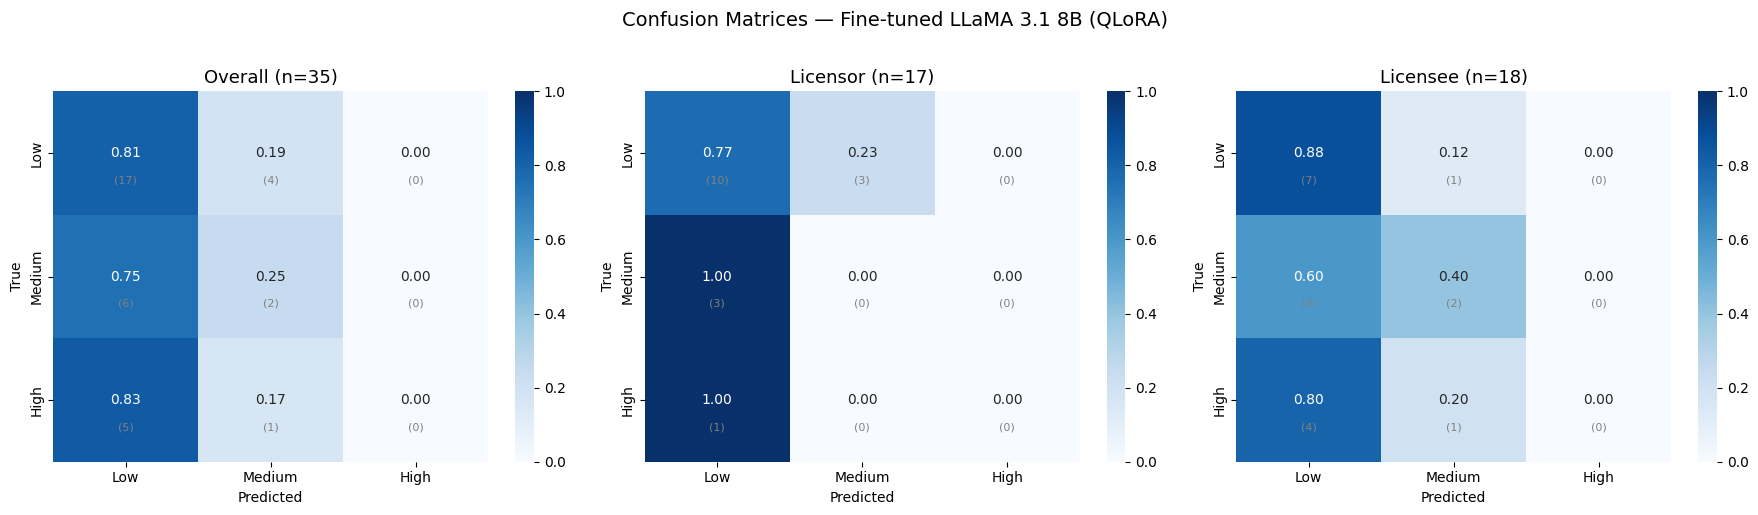

Saved: confusion_matrices.png


In [9]:
# ── Confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

splits = [
    ("Overall",   list(range(len(y_true))),  y_true, y_pred),
    ("Licensor",  [i for i,p in enumerate(parties) if p=="Licensor"],  None, None),
    ("Licensee",  [i for i,p in enumerate(parties) if p=="Licensee"],  None, None),
]

for ax, (title, idx, yt, yp) in zip(axes, splits):
    if yt is None:
        yt = [y_true[i] for i in idx]
        yp = [y_pred[i] for i in idx]
    cm = confusion_matrix(yt, yp, labels=LABELS)
    # Normalize by row (true label) for readability
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS, ax=ax,
        vmin=0, vmax=1,
    )
    # Overlay raw counts
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j+0.5, i+0.72, f"({cm[i,j]})",
                    ha="center", va="center", fontsize=8, color="gray")
    ax.set_title(f"{title} (n={len(yt)})", fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — Fine-tuned LLaMA 3.1 8B (QLoRA)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [10]:
# ── High↔Low flip analysis ────────────────────────────────────
# These are the worst misclassifications — flag them explicitly
flips = [
    (i, y_true[i], y_pred[i], parties[i])
    for i in range(len(y_true))
    if set([y_true[i], y_pred[i]]) == {"High", "Low"}
]

print(f"High↔Low flips: {len(flips)}")
if flips:
    print(f"{'Idx':>4}  {'True':>7}  {'Pred':>7}  Party")
    print("-" * 35)
    for idx, true, pred, party in flips:
        print(f"{idx:>4}  {true:>7}  {pred:>7}  {party}")

High↔Low flips: 5
 Idx     True     Pred  Party
-----------------------------------
   3     High      Low  Licensee
  12     High      Low  Licensee
  14     High      Low  Licensee
  26     High      Low  Licensor
  31     High      Low  Licensee


In [11]:
# ── Prediction distribution ───────────────────────────────────
from collections import Counter

print("Prediction distribution (val):")
pred_dist = Counter(y_pred)
true_dist = Counter(y_true)
print(f"{'Label':>8}  {'True':>6}  {'Pred':>6}")
print("-" * 26)
for label in LABELS:
    print(f"{label:>8}  {true_dist[label]:>6}  {pred_dist[label]:>6}")

# Check if model is still collapsing toward Medium (baseline failure mode)
medium_frac = pred_dist.get("Medium", 0) / len(y_pred)
print(f"\nMedium prediction rate: {medium_frac:.1%}")
if medium_frac > 0.6:
    print("⚠️  Model may still be collapsing toward Medium — consider more epochs or checking annotations.")
else:
    print("✓  No medium-collapse detected.")

Prediction distribution (val):
   Label    True    Pred
--------------------------
     Low      21      28
  Medium       8       7
    High       6       0

Medium prediction rate: 20.0%
✓  No medium-collapse detected.


## 11. Qualitative Check — Sample Predictions

In [12]:
# Show a few examples with full generated output for manual inspection
import textwrap

def show_sample(idx):
    ex = val_examples[idx]
    prompt = get_prompt_only(ex["text"])
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=120, do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    generated = tokenizer.decode(new_tokens, skip_special_tokens=True)

    party  = ex.get("_meta", {}).get("party", "?")
    true_l = y_true[idx]
    pred_l = y_pred[idx]
    match  = "✓" if true_l == pred_l else "✗"

    print(f"{'─'*60}")
    print(f"Example #{idx}  |  Party: {party}  |  True: {true_l}  |  Pred: {pred_l}  {match}")
    print(f"{'─'*60}")
    print("Generated output:")
    print(textwrap.fill(generated.strip(), width=80))
    print()

# Show a correct prediction, a wrong one, and a High-risk example
correct_idx   = next((i for i in range(len(y_true)) if y_true[i] == y_pred[i]), 0)
incorrect_idx = next((i for i in range(len(y_true)) if y_true[i] != y_pred[i]), 1)
high_idx      = next((i for i in range(len(y_true)) if y_true[i] == "High"), 2)

for idx in [correct_idx, incorrect_idx, high_idx]:
    show_sample(idx)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


────────────────────────────────────────────────────────────
Example #0  |  Party: Licensee  |  True: Low  |  Pred: Low  ✓
────────────────────────────────────────────────────────────
Generated output:
Risk Level: Low Explanation: The clause only requires CytoDyn to maintain
confidentiality, which is a standard obligation and does not impose any cost or
restriction on the Licensee.

────────────────────────────────────────────────────────────
Example #2  |  Party: Licensee  |  True: High  |  Pred: Medium  ✗
────────────────────────────────────────────────────────────
Generated output:
Risk Level: Medium Explanation: The Licensee must pay for audits and any
underpaid fees, which could be costly.

────────────────────────────────────────────────────────────
Example #2  |  Party: Licensee  |  True: High  |  Pred: Medium  ✗
────────────────────────────────────────────────────────────
Generated output:
Risk Level: Medium Explanation: The Licensee must pay for audits and any
underpaid fees, 